In [ ]:
# Day 3 of ML

In [52]:
# import the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_diabetes

In [53]:
# EDA on the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
# Create a DataFrame for EDA
diabetes_df = pd.DataFrame(X, columns=diabetes.feature_names)
diabetes_df['target'] = y
print(diabetes_df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

In [3]:
# training model using only bmi feature
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = diabetes_df[['bmi']]
Y = diabetes_df['target']
model.fit(X, Y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


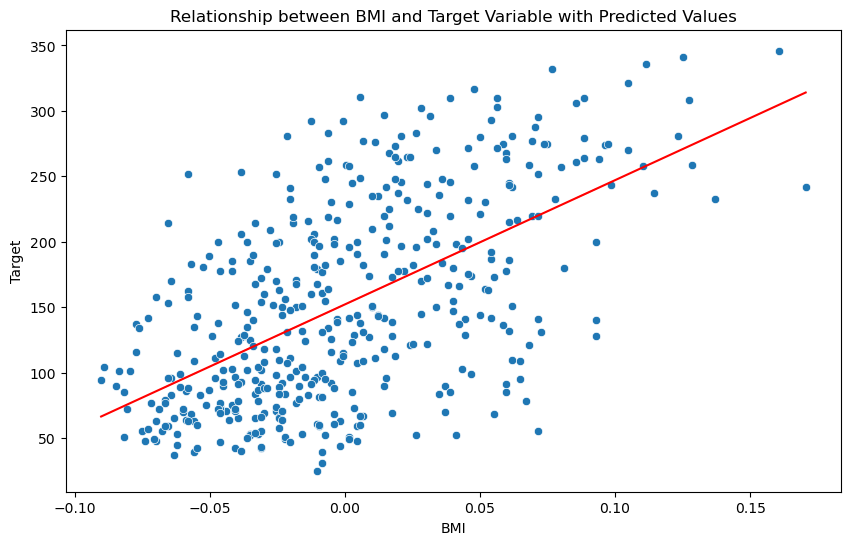

In [5]:
# plotting chart to see the relationship between bmi and target variable and predicted data points
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='target', data=diabetes_df)
# Predicting values using the model
y_pred = model.predict(X)
# Adding predicted values to the DataFrame
diabetes_df['predicted_target'] = y_pred
sns.lineplot(x='bmi', y='predicted_target', data=diabetes_df, color='red')
plt.title('Relationship between BMI and Target Variable with Predicted Values')
plt.xlabel('BMI')
plt.ylabel('Target')
plt.show()

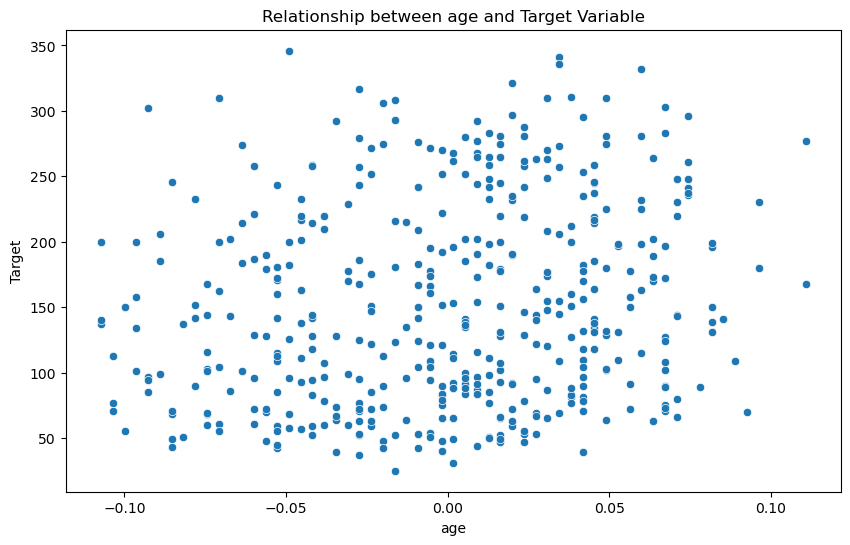

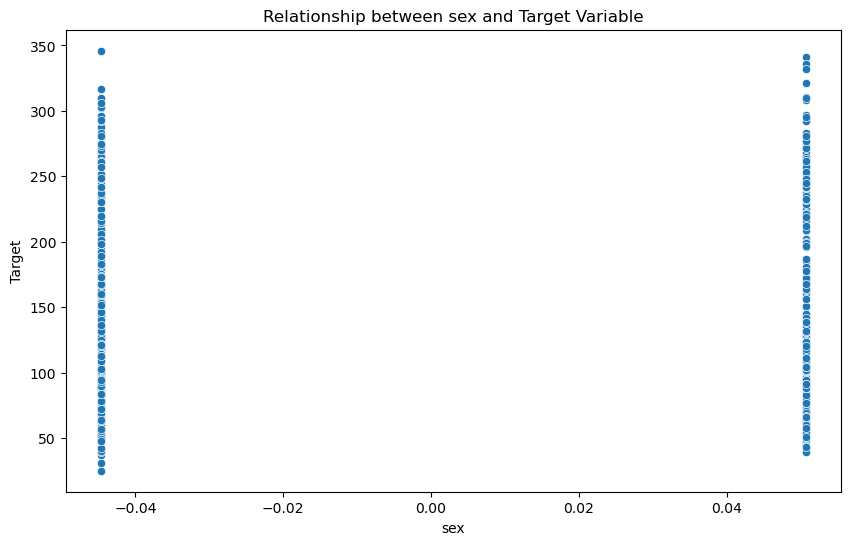

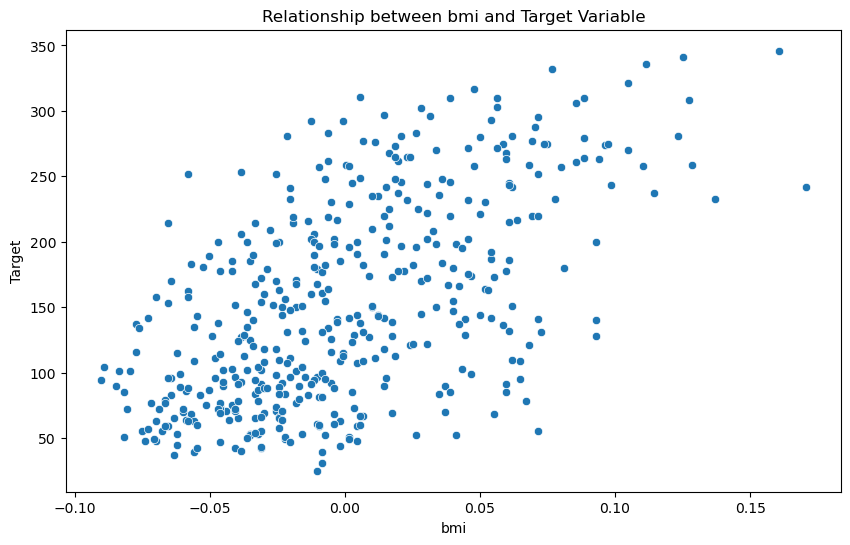

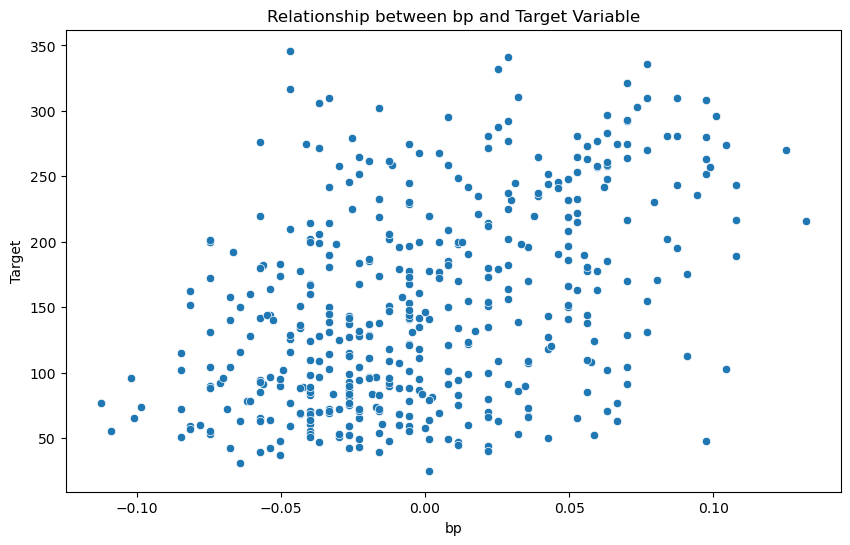

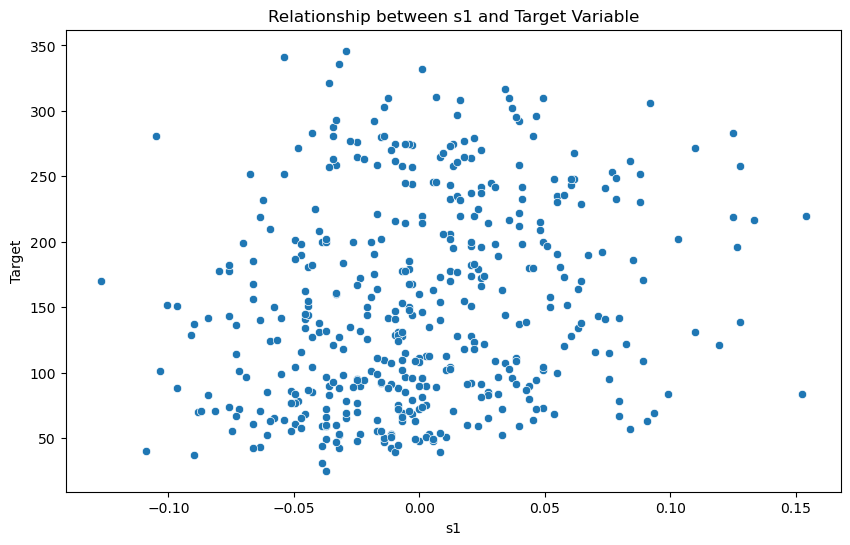

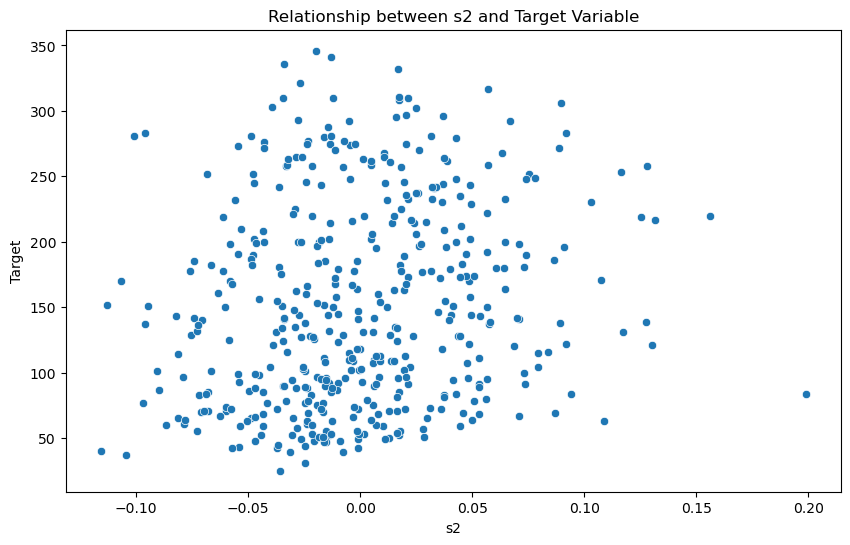

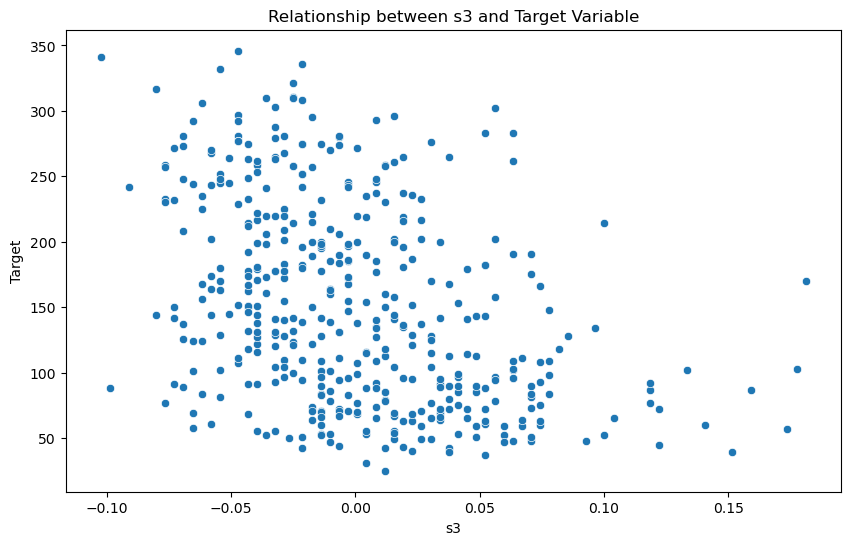

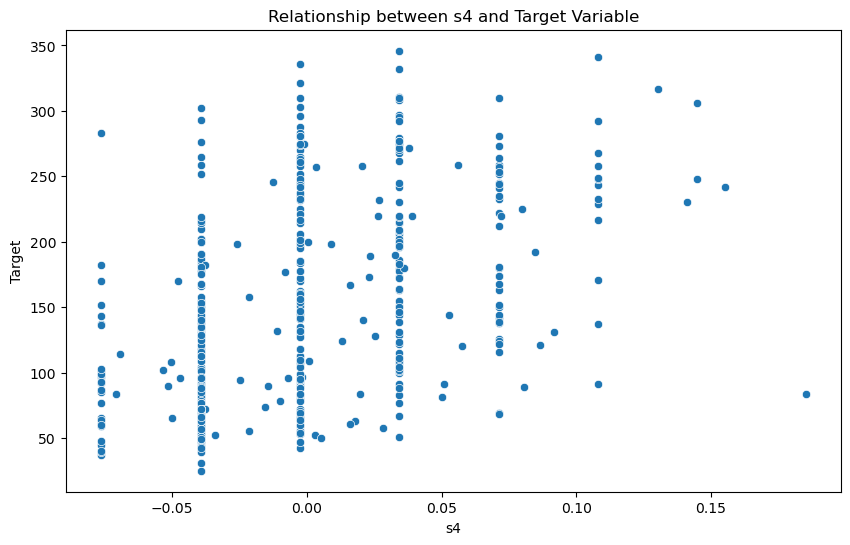

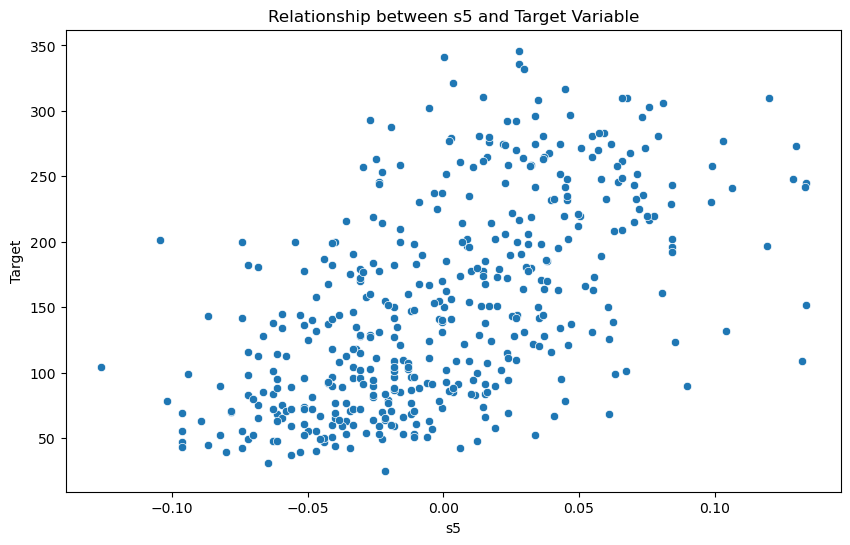

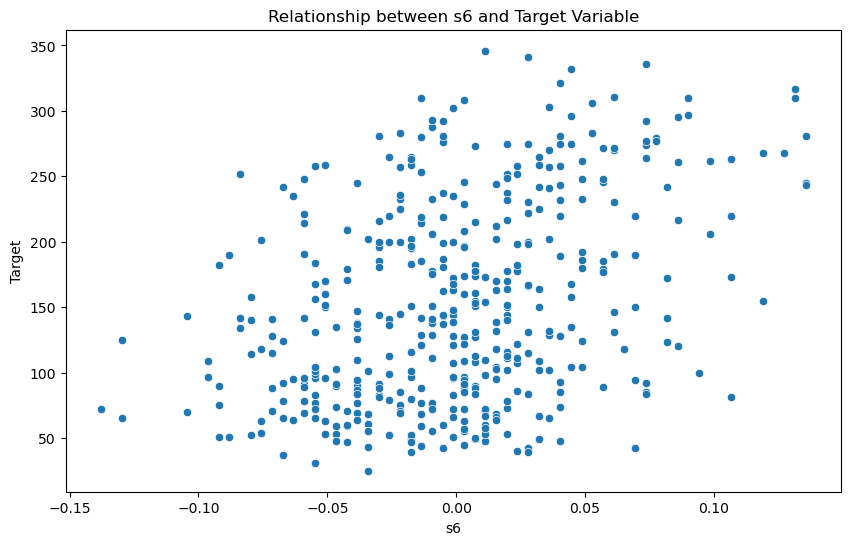

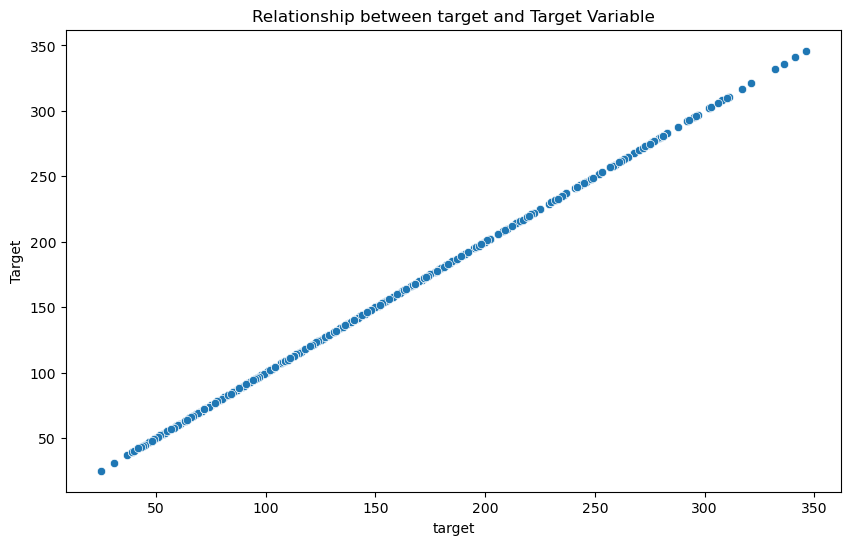

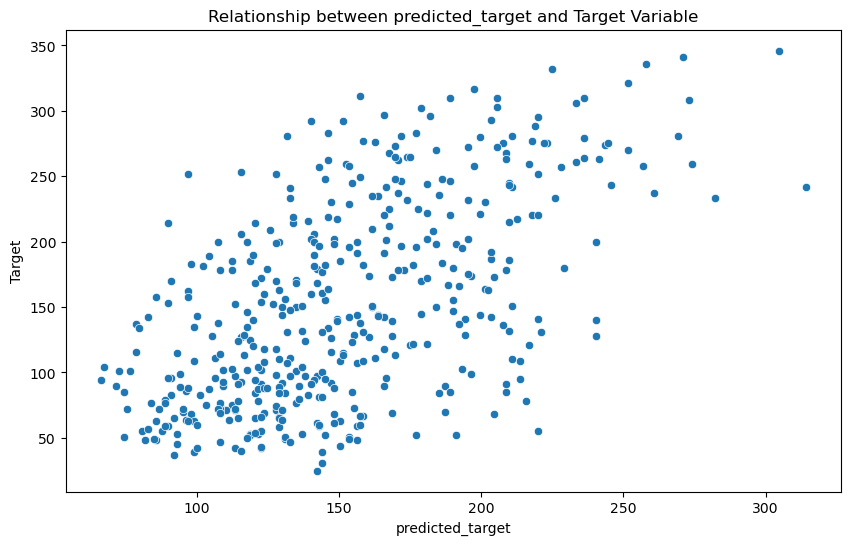

In [6]:
# EDA to see the relationship between all features and target variable

for col in diabetes_df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=col, y='target', data=diabetes_df)
    plt.title(f'Relationship between {col} and Target Variable')
    plt.xlabel(col)
    plt.ylabel('Target')
    plt.show()

In [60]:
# finding duplicate values in the dataset
duplicate_rows = diabetes_df[diabetes_df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


In [61]:
# checking missing values in the dataset
missing_values = diabetes_df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


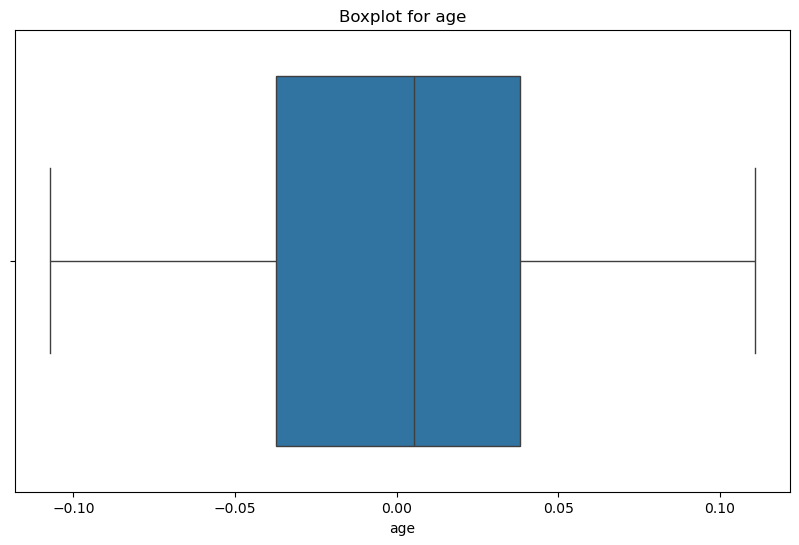

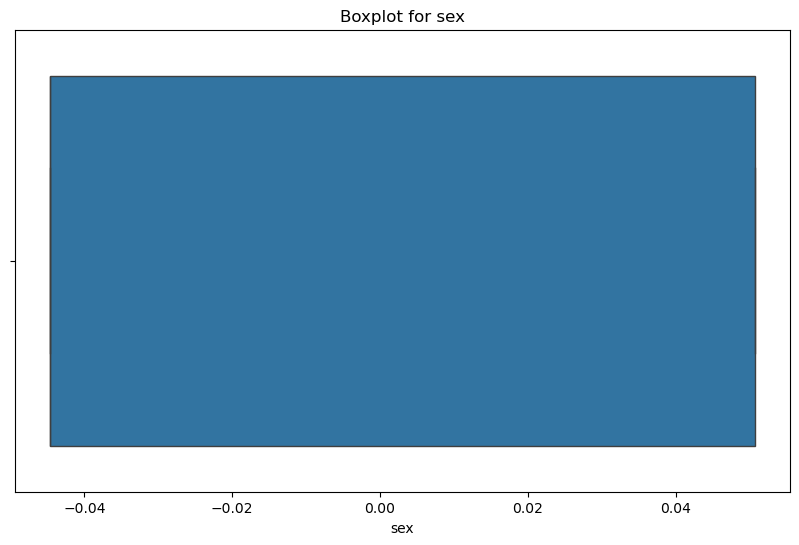

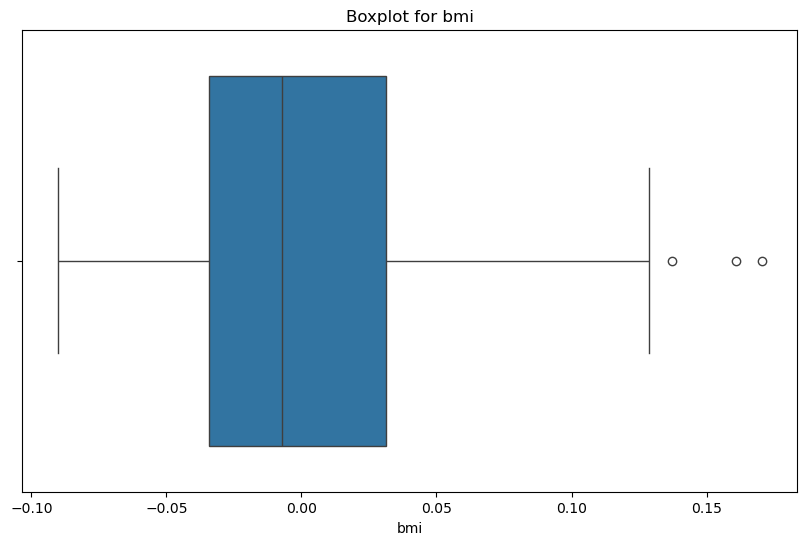

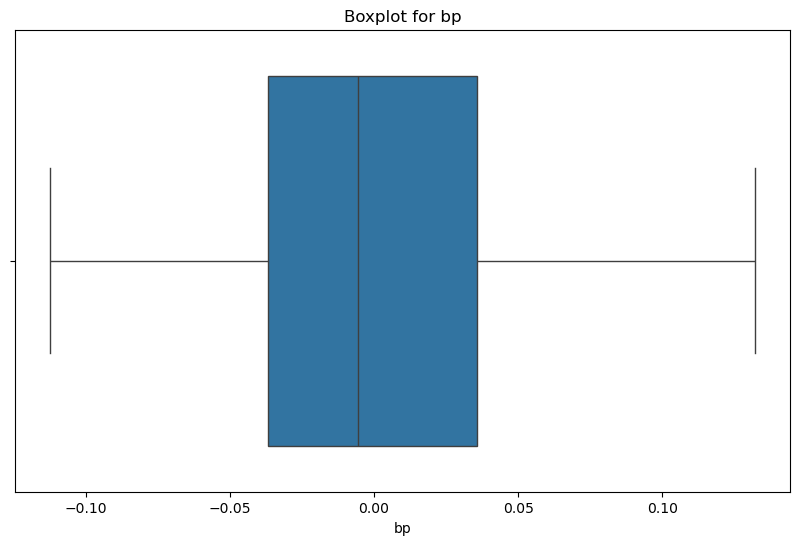

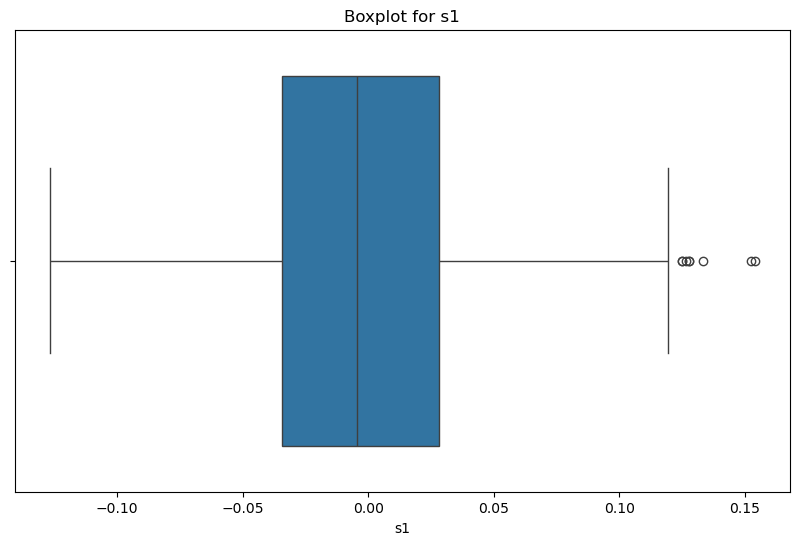

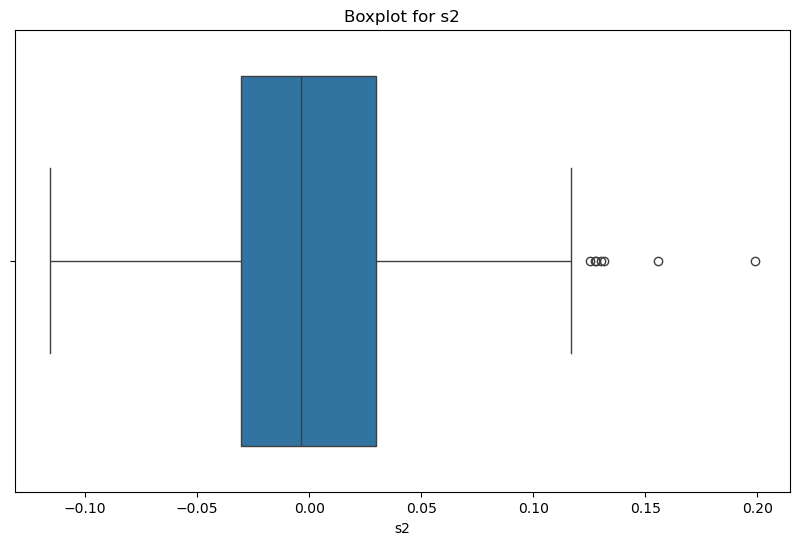

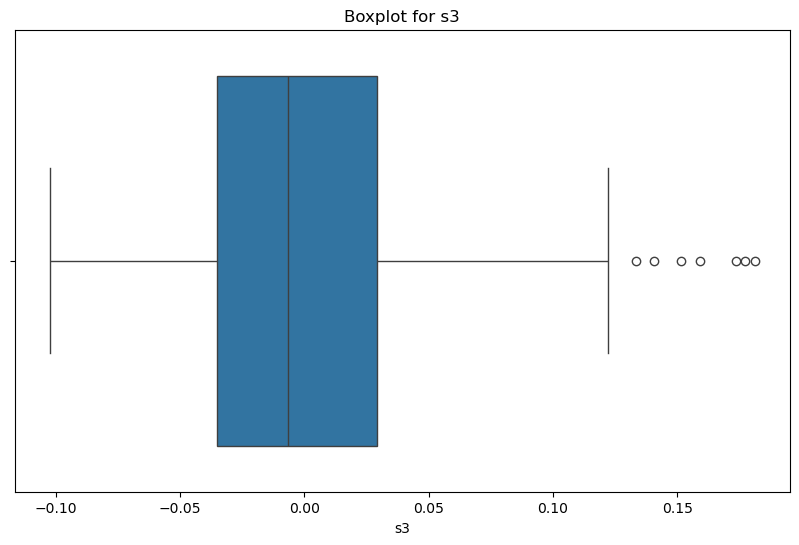

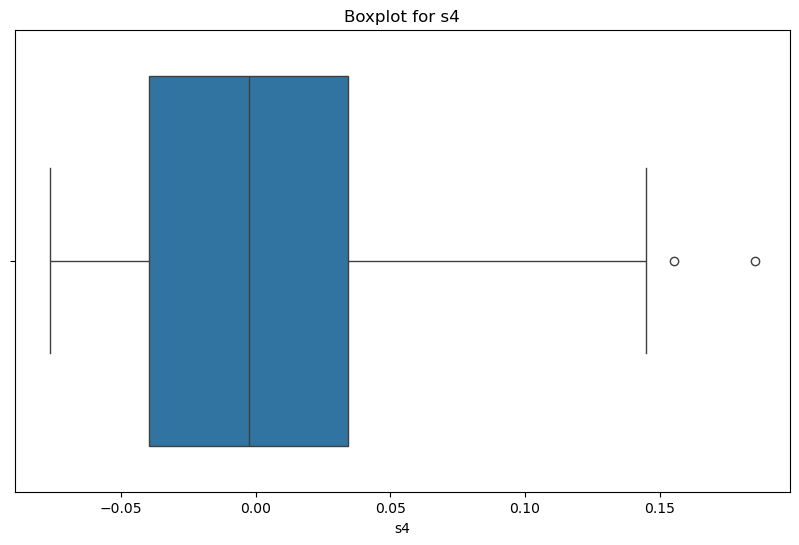

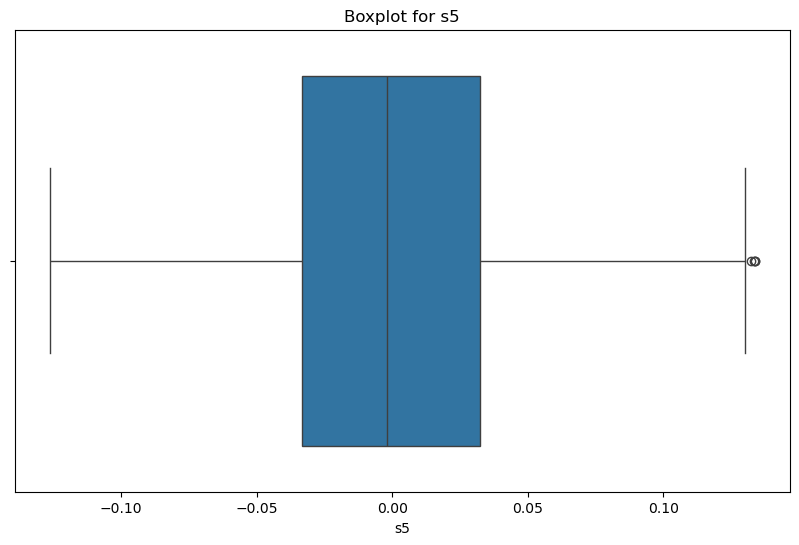

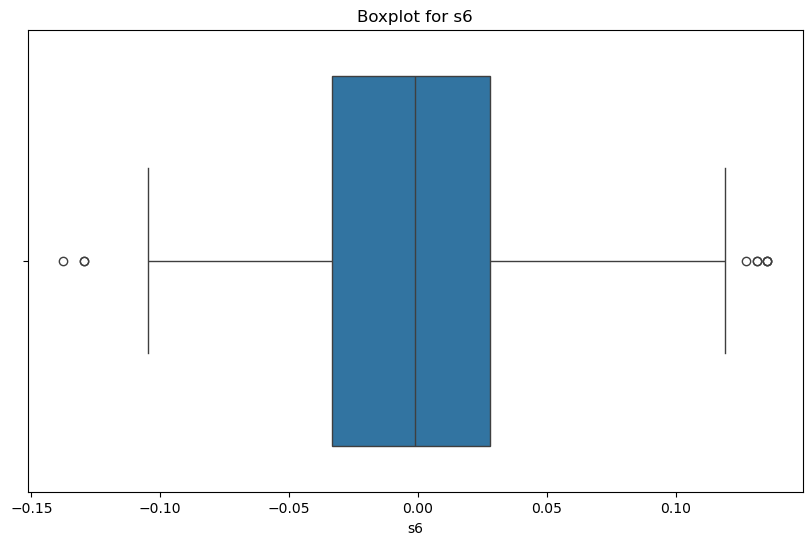

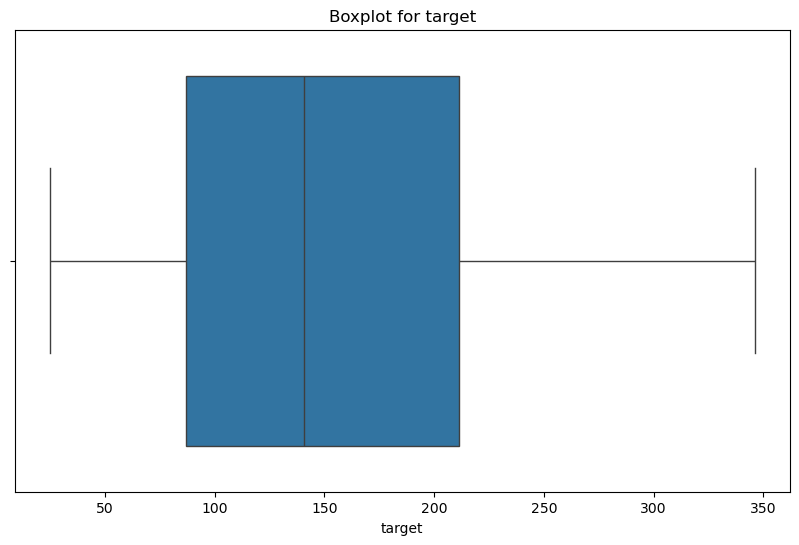

In [62]:
# checking if any outliers are present in the dataset using boxplot
for col in diabetes_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=diabetes_df[col])
    plt.title(f'Boxplot for {col}')
    plt.xlabel(col)
    plt.show()

In [64]:
# analysingthe boxplot, we can see that there are some outliers in the dataset. We can handle them using IQR method or Z-score method. For simplicity, we will use IQR method to handle outliers in the dataset.
Q1 = diabetes_df.quantile(0.25)
Q3 = diabetes_df.quantile(0.75)
IQR = Q3 - Q1
# Removing outliers
diabetes_df_new2 = diabetes_df[~((diabetes_df < (Q1 - 1.5 * IQR)) | (diabetes_df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"Shape of the dataset after removing outliers: {diabetes_df_new2.shape}")
print("Shape of the dataset before removing outliers:", diabetes_df.shape)

Shape of the dataset after removing outliers: (411, 11)
Shape of the dataset before removing outliers: (442, 11)


In [65]:
# getting the correlation between all features and target variable
correlation_matrix = diabetes_df_new2.corr()
print("Correlation Matrix:")
print(correlation_matrix['target'].sort_values(ascending=False))


Correlation Matrix:
target    1.000000
bmi       0.568104
s5        0.558874
bp        0.437351
s4        0.409703
s6        0.341035
age       0.199981
s1        0.198914
s2        0.151457
sex       0.024965
s3       -0.382829
Name: target, dtype: float64


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [71]:
diabetes_df_new2.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000
mean,-0.000035,0.000352,-0.001478,-0.000254,-0.004133,-0.002347,-0.001573,-0.002205,-0.002924,-0.001823,149.970803
std,0.048200,0.047644,0.045594,0.046634,0.043897,0.044178,0.043387,0.044260,0.045482,0.044274,75.772954
min,-0.107226,-0.044642,-0.090275,-0.112399,-0.126781,-0.115613,-0.102307,-0.076395,-0.126097,-0.104630,25.000000
25%,-0.034575,-0.044642,-0.034229,-0.033213,-0.035968,-0.030437,-0.032356,-0.039493,-0.034522,-0.034215,85.500000
50%,0.005383,-0.044642,-0.007284,-0.005670,-0.005697,-0.003819,-0.006584,-0.002592,-0.005142,-0.001078,139.000000
75%,0.038076,0.050680,0.028284,0.032769,0.023198,0.026087,0.026550,0.034309,0.028339,0.027917,202.000000
max,0.110727,0.050680,0.128521,0.132044,0.109883,0.117056,0.122273,0.145012,0.130079,0.119043,341.000000


In [66]:
# create a model using features bmi, bp, s3, s5
# removing outliers from the target variable and the dataset
Q1 = diabetes_df_new2['target'].quantile(0.25)
Q3 = diabetes_df_new2['target'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
diabetes_df_new3 = diabetes_df_new2[(diabetes_df_new2['target'] >= lower_bound) & (diabetes_df_new2['target'] <= upper_bound)]

model = LinearRegression()
X = diabetes_df_new3[['bmi', 's5']]

Y = diabetes_df_new3['target']

# splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42) # random_state is used to ensure that the split is reproducible
# training the model on the training data
model.fit(X_train, y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
# prnting the coefficients of the model
print("Coefficients of the model:")
for feature, coef in zip(X.columns, model.coef_): # zip is used to iterate over the features and coefficients together
    print(f"{feature}: {coef:.2f}") # .2f is used to round the coefficients to 2 decimal places

# print the intercept of the model
print(f"Intercept of the model: {model.intercept_:.2f}") 

Coefficients of the model:
bmi: 620.93
s5: 692.00
Intercept of the model: 153.74


In [68]:
# checking accuracy of the model
from sklearn.metrics import mean_squared_error
predicted = model.predict(X_train)
mse = mean_squared_error(y_train, predicted)
print(f"Mean Squared Error of the model: {mse:.2f}")
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error of the model: {rmse:.2f}")


Mean Squared Error of the model: 3112.96
Root Mean Squared Error of the model: 55.79


In [69]:
# accuracy of the model on the test data
predicted_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, predicted_test)
print(f"Mean Squared Error of the model on test data: {mse_test:.2f}")
rmse_test = np.sqrt(mse_test)
print(f"Root Mean Squared Error of the model on test data: {rmse_test:.2f}")


Mean Squared Error of the model on test data: 3594.37
Root Mean Squared Error of the model on test data: 59.95


R-squared of the model: 0.43
Goodness of Fit of the model: 0.43
R-squared of the model on test data: 0.46


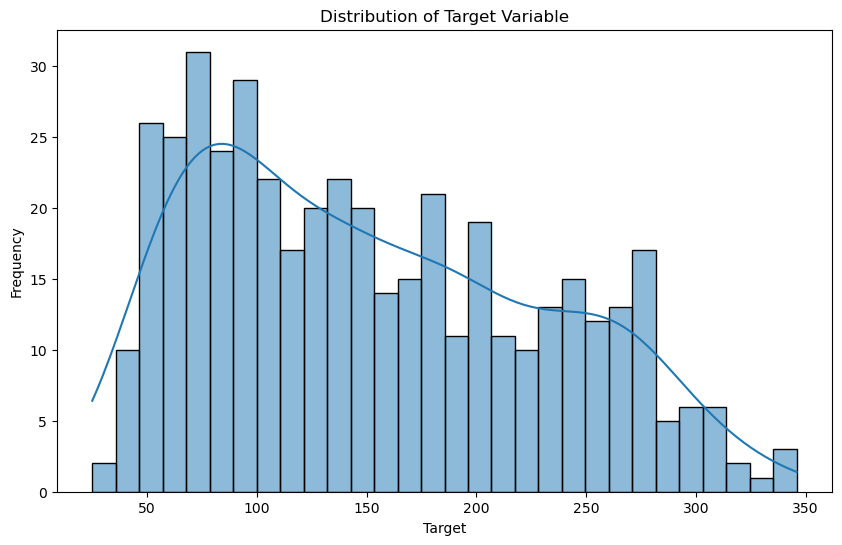

In [70]:
# accuracy of the model using R-squared
r_squared = model.score(X_train, y_train)
print(f"R-squared of the model: {r_squared:.2f}")  

# goodness of fit of the model using R-squared
goodness_of_fit = r_squared
print(f"Goodness of Fit of the model: {goodness_of_fit:.2f}")

# score of the model on the test data using R-squared
r_squared_test = model.score(X_test, y_test)
print(f"R-squared of the model on test data: {r_squared_test:.2f}")

# plotting histogram to see the distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(diabetes_df['target'], bins=30, kde=True)
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()


In [59]:
# feature importance of the model using coefficients
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
print("Feature Importance based on Coefficients:")
print(feature_importance)


Feature Importance based on Coefficients:
  Feature  Coefficient
0     bmi   593.310480
3      s5   428.587088
1      bp   302.949097
2      s3  -225.735808


EDA and preprocessing of features
Finding null values and filling it with mean

In [77]:
# EDA example

df = pd.DataFrame({
    'Feature1': [1, 2, np.nan, 4, 5],
    'Feature2': [5, 4, 3, 2, 1],
    'Feature3': [2, 3, 4, 5, 6],
    'Target': [2, 3, 4, 5, 6]
})

print(df)

df.describe()

   Feature1  Feature2  Feature3  Target
0       1.0         5         2       2
1       2.0         4         3       3
2       NaN         3         4       4
3       4.0         2         5       5
4       5.0         1         6       6


,Feature1,Feature2,Feature3,Target
count,4.000000,5.000000,5.000000,5.000000
mean,3.000000,3.000000,4.000000,4.000000
std,1.825742,1.581139,1.581139,1.581139
min,1.000000,1.000000,2.000000,2.000000
25%,1.750000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,4.000000
75%,4.250000,4.000000,5.000000,5.000000
max,5.000000,5.000000,6.000000,6.000000


In [75]:
df.isna()

,Feature1,Feature2,Feature3,Target
0,False,False,False,False
1,False,False,False,False
2,True,False,False,False
3,False,False,False,False
4,False,False,False,False


In [78]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

impute = imputer.fit(df[['Feature1']])



In [79]:
df_new = df.copy()
df_new['Feature1'] = imputer.transform(df[['Feature1']])

In [80]:
print(df_new)

   Feature1  Feature2  Feature3  Target
0       1.0         5         2       2
1       2.0         4         3       3
2       3.0         3         4       4
3       4.0         2         5       5
4       5.0         1         6       6


In [81]:
# filling missing values with mean using fillna method
df_new2 = df.copy()

print(df_new2)

df_new2['Feature1'] = df_new2['Feature1'].fillna(df_new2['Feature1'].mean())

print(df_new2)

   Feature1  Feature2  Feature3  Target
0       1.0         5         2       2
1       2.0         4         3       3
2       NaN         3         4       4
3       4.0         2         5       5
4       5.0         1         6       6
   Feature1  Feature2  Feature3  Target
0       1.0         5         2       2
1       2.0         4         3       3
2       3.0         3         4       4
3       4.0         2         5       5
4       5.0         1         6       6
